# Phase 2 — Ingestion et gouvernance des données

**Projet :** prédiction de résiliation client (churn) — éditeur SaaS B2B
**Certification :** CISIA — Concevoir et implémenter une solution d'intelligence artificielle
**Objet de ce carnet :** établir ce que sont réellement les données, comment elles seront
gérées dans le temps, où elles seront stockées et ce qu'elles contiennent de sensible.

---

## Ce que cette phase décide

La phase de cadrage a défini *quel problème résoudre*. Celle-ci répond à quatre questions
qui conditionnent tout ce qui suit.

| Question | Section | Conséquence si elle est mal traitée |
|---|---|---|
| Que contiennent réellement les données ? | § 1 | Un défaut non vu devient un biais de modèle |
| Comment les données vivent-elles dans le temps ? | § 2 | Impossible de reproduire un résultat, ni de purger ce qui doit l'être |
| Où sont-elles stockées, et pourquoi là ? | § 3 | Un choix par défaut devient une dette permanente |
| Que contiennent-elles de sensible ? | § 4 | Exposition juridique et perte de confiance |

**Principe de travail.** Rien n'est affirmé ici sans être mesuré. Les défauts sont comptés,
les taux d'appariement calculés, la présence de données personnelles détectée — plutôt que
supposée.

In [1]:
# --- Environment and data ------------------------------------------------------------
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make the package importable whether or not it is installed: this notebook must be
# replayable straight from an unzipped archive, without running `uv sync`.
RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

from churn_saas.donnees.empreinte import (
    empreinte_donnees,
    manifeste_stable,
    verifier_manifeste,
)
from churn_saas.donnees.gouvernance import (
    comparer_stockage,
    exemples_anonymises,
    scanner_texte_libre,
    table_cycle_de_vie,
    table_sensibilite,
)
from churn_saas.donnees.ingestion import charger_bronze
from churn_saas.donnees.schema import auditer_qualite, controler_jointure, decrire_schema
from churn_saas.donnees.silver import construire_silver
from churn_saas.notebook import afficher_tableau

# Pandas truncates long strings with an ellipsis. The rationale columns below carry the
# argument, so every cell must show its full content.
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

PALETTE = {"principal": "#2a6f9e", "accent": "#b03030", "neutre": "#8a8a8a",
           "ok": "#2e7d52", "attention": "#c9861a"}

SOURCES = {
    "jeu complet": RACINE / "data" / "raw" / "churn_saas_complet.csv",
    "échantillon": RACINE / "data" / "raw" / "churn_saas_echantillon.csv",
    "catalogue des plans": RACINE / "data" / "raw" / "catalogue_plans.csv",
}

for nom, chemin in SOURCES.items():
    taille = chemin.stat().st_size
    # A Git-LFS pointer weighs ~130 bytes: detecting it here avoids a confusing failure
    # further down (see section 3).
    alerte = "  <- pointeur Git-LFS, données absentes" if taille < 1000 and nom != "catalogue des plans" else ""
    print(f"{nom:22} {taille:>9,} octets{alerte}".replace(",", " "))

jeu complet              727 622 octets
échantillon                7 824 octets
catalogue des plans          203 octets


---

# 1. Lire et ingérer les sources, décrire le schéma

## 1.1 Lecture brute, sans transformation

Les trois fichiers sont lus **entièrement en texte**. Laisser la bibliothèque deviner les
types masquerait précisément les défauts que cette phase doit mettre au jour : une colonne
contenant `"33,3"` serait silencieusement traitée comme du texte, et l'on ne saurait pas si
c'est voulu ou subi.

In [2]:
brut = charger_bronze(SOURCES["jeu complet"])
catalogue = charger_bronze(SOURCES["catalogue des plans"])
echantillon = charger_bronze(SOURCES["échantillon"])

volumetrie = pd.DataFrame([
    ("Jeu complet", len(brut), brut.shape[1], "Apprentissage et évaluation"),
    ("Échantillon", len(echantillon), echantillon.shape[1], "Test du pipeline de bout en bout"),
    ("Catalogue des plans", len(catalogue), catalogue.shape[1], "Enrichissement par jointure"),
], columns=["Source", "Lignes", "Colonnes", "Usage prévu"])

afficher_tableau(volumetrie, "Sources ingérées")

Source,Lignes,Colonnes,Usage prévu
Jeu complet,5035,29,Apprentissage et évaluation
Échantillon,50,29,Test du pipeline de bout en bout
Catalogue des plans,4,6,Enrichissement par jointure


## 1.2 Schéma déclaré : rôle de chaque colonne

Le type d'une colonne ne dit pas ce qu'on a le droit d'en faire. Le **rôle**, si.

Un identifiant ne doit jamais atteindre le modèle. Une cible ne doit jamais devenir une
variable explicative. Une variable postérieure à la décision doit être écartée quelle que
soit sa qualité prédictive — elle est même d'autant plus dangereuse qu'elle prédit bien.

Cette table est donc la première décision de la phase : elle fixe le contrat.

In [3]:
schema = decrire_schema(brut)
afficher_tableau(schema, "Schéma des données : rôle déclaré, forme attendue, complétude")

colonne,role,forme attendue,manquants %,valeurs distinctes,exemple
client_id,identifiant,directement exploitable,0.00,5000,CLI-002447
date_souscription,contractuel,date en formats mêlés,0.00,1415,31/01/2024
jour_souscription,contractuel,directement exploitable,0.00,7,mercredi
secteur,signalétique,directement exploitable,5.02,28,Finance
pays,signalétique,directement exploitable,3.99,6,France
taille_entreprise,signalétique,directement exploitable,0.00,12,TPE
plan,contractuel,directement exploitable,0.00,16,STARTER
anciennete_mois,contractuel,directement exploitable,0.00,36,12
sieges_souscrits,contractuel,directement exploitable,0.00,468,3
utilisateurs_actifs,usage,directement exploitable,0.00,316,0


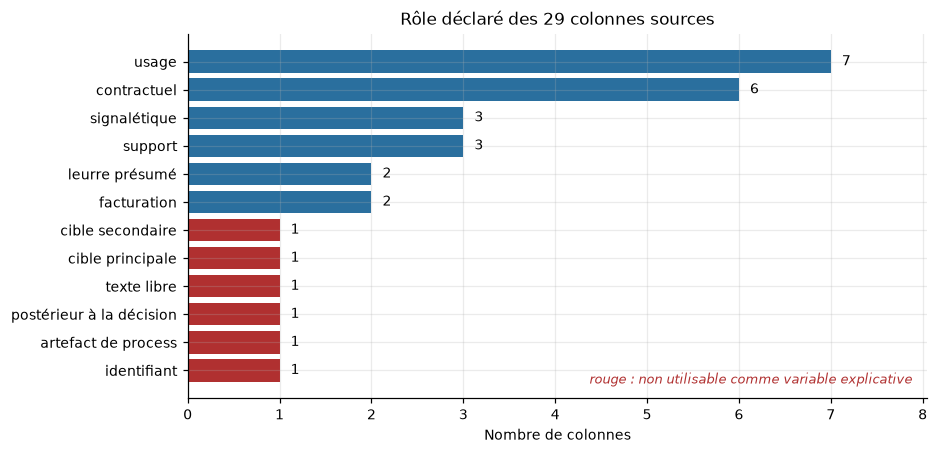

In [4]:
# --- Figure: declared roles at a glance ---------------------------------------------
comptage = schema["role"].value_counts().sort_values()
# Colour by whether the role is usable as a feature: the distinction that matters.
NON_MODELISABLES = {"identifiant", "cible principale", "cible secondaire",
                    "postérieur à la décision", "texte libre", "artefact de process"}
couleurs = [PALETTE["accent"] if r in NON_MODELISABLES else PALETTE["principal"]
            for r in comptage.index]

fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.barh(range(len(comptage)), comptage.to_numpy(), color=couleurs)
ax.set_yticks(range(len(comptage)))
ax.set_yticklabels(comptage.index)
for i, v in enumerate(comptage):
    ax.text(v + 0.12, i, str(v), va="center", fontsize=9)
ax.set_xlabel("Nombre de colonnes")
ax.set_title("Rôle déclaré des 29 colonnes sources")
ax.text(0.98, 0.04,
        "rouge : non utilisable comme variable explicative",
        transform=ax.transAxes, ha="right", fontsize=8.5,
        color=PALETTE["accent"], style="italic")
ax.set_xlim(0, comptage.max() * 1.15)
plt.tight_layout(); plt.show()

**Lecture.** Sur 29 colonnes, six ne peuvent pas servir de variable explicative, pour des
motifs entièrement différents : un identifiant, deux cibles, une variable postérieure à la
décision, un champ de texte libre, un artefact de process.

Ces motifs ne sont pas interchangeables, et c'est important pour la suite : le référentiel
distingue l'exclusion éthique de l'exclusion technique. Justifier les six par « ça dégrade
le modèle » ne satisferait ni l'une ni l'autre.

## 1.3 Ce que les données sont réellement : audit de qualité

Le schéma dit ce que les données prétendent être. L'audit dit ce qu'elles sont. L'écart
entre les deux est le travail de cette phase.

In [5]:
audit = auditer_qualite(brut)
afficher_tableau(audit, "Défauts détectés, portée et conséquence si non traités")

défaut,portée,conséquence si non traité
Doublons stricts,35 lignes sur 5035,Sur-représentation de comptes identiques : le modèle apprend deux fois les mêmes exemples et les métriques sont optimistes
BOM UTF-8 en tête de fichier,absent après lecture utf-8-sig,La première colonne s'appelle ﻿client_id : toute sélection par nom échoue sans message explicite
Nombres stockés en texte,"5 colonnes : taux_adoption_pct, heures_usage_30j, delai_reponse_support_h, revenu_mensuel_recurrent_eur, valeur_vie_client_eur","Colonnes traitées comme catégorielles : une valeur = une modalité, toute relation d'ordre est perdue"
Dates en formats mêlés,"1621 en JJ/MM/AAAA, 1705 en AAAA-MM-JJ",Parsing partiel : les formats non reconnus deviennent NaT sans alerte
Casse et espaces hétérogènes,"secteur, plan, taille_entreprise",Jointure sur `plan` silencieusement incomplète : les lignes non appariées disparaissent sans erreur


**Le défaut le plus dangereux n'est pas le plus visible.** Des nombres stockés en texte
produisent une erreur franche dès qu'on tente un calcul : on s'en aperçoit. Une casse
hétérogène sur une clé de jointure, elle, ne produit **aucune erreur** — les lignes non
appariées disparaissent simplement.

C'est cette catégorie de défaut qu'il faut mesurer, pas supposer. Le tableau ci-dessous
le quantifie : **2 302 lignes sur 5 035 ne seraient pas rapprochées**, soit près d'une
sur deux.

Un échec total se remarquerait — un tableau vide, une colonne absente. Un échec à 46 %
ne se remarque pas : les données restent plausibles, les moyennes restent crédibles, et
l'analyse porte sur la moitié du portefeuille sans que rien ne l'indique.

In [6]:
controle = controler_jointure(brut, catalogue, cle="plan")
afficher_tableau(controle, "Jointure sur `plan` : effet de la normalisation de la clé")

méthode de jointure,taux d'appariement,lignes perdues
Sur la valeur brute,54.3%,2302
"Après normalisation (casse, espaces)",100.0%,0


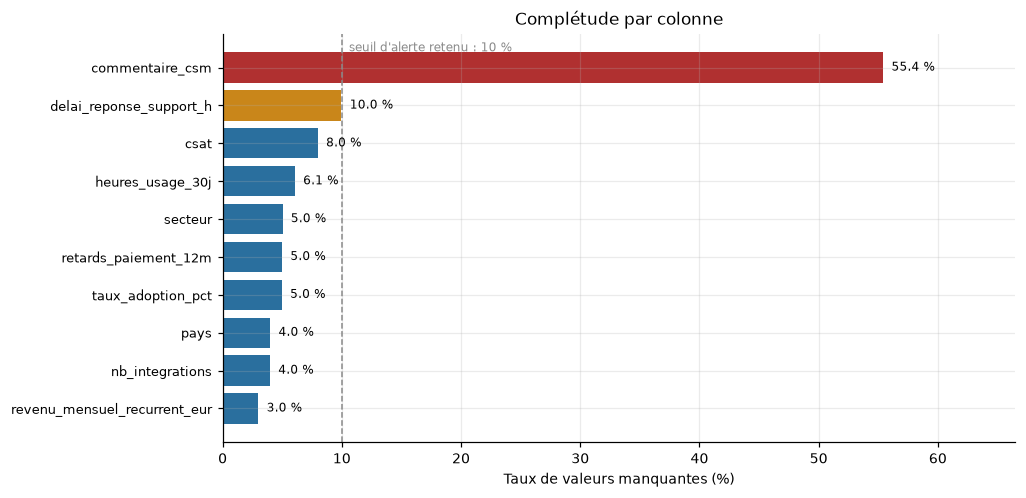

Colonnes concernées : 10 sur 29
Taux médian sur ces colonnes : 5.0 %


In [7]:
# --- Figure: missing rate by column -------------------------------------------------
manquants = (brut.isna().mean() * 100).sort_values(ascending=False)
manquants = manquants[manquants > 0]

fig, ax = plt.subplots(figsize=(9.4, 4.6))
couleurs = [PALETTE["accent"] if v > 50 else
            PALETTE["attention"] if v > 8 else
            PALETTE["principal"] for v in manquants]
ax.barh(range(len(manquants)), manquants.to_numpy(), color=couleurs)
ax.set_yticks(range(len(manquants)))
ax.set_yticklabels(manquants.index, fontsize=8.5)
ax.invert_yaxis()
for i, v in enumerate(manquants):
    ax.text(v + 0.7, i, f"{v:.1f} %", va="center", fontsize=8)
ax.axvline(10, color=PALETTE["neutre"], ls="--", lw=1)
ax.text(10.6, -0.35, "seuil d'alerte retenu : 10 %",
        fontsize=8, color=PALETTE["neutre"], va="bottom")
ax.set_xlabel("Taux de valeurs manquantes (%)")
ax.set_title("Complétude par colonne")
ax.set_xlim(0, max(manquants.max() * 1.2, 15))
plt.tight_layout(); plt.show()

print(f"Colonnes concernées : {len(manquants)} sur {brut.shape[1]}")
print(f"Taux médian sur ces colonnes : {manquants.median():.1f} %")

**Une régularité qui appelle une vérification.** Hors `commentaire_csm`, les taux de
valeurs manquantes se situent tous entre 3 et 10 %. Cette régularité suggère une absence
introduite au hasard plutôt qu'un mécanisme métier.

L'hypothèse mérite d'être testée, car elle change la stratégie : si l'absence d'une donnée
d'usage était corrélée au départ du client — un compte désengagé cessant d'être suivi —
alors **le manque serait lui-même un signal**, à conserver plutôt qu'à combler.

In [8]:
# --- Is a missing value itself a signal? --------------------------------------------
cible = pd.to_numeric(brut["churn"], errors="coerce")
taux_global = cible.mean()

lignes = []
for colonne in manquants.index:
    if colonne == "churn":
        continue
    absent = brut[colonne].isna()
    if absent.sum() < 30:
        continue
    lignes.append({
        "Colonne": colonne,
        "Taux de churn si renseignée": f"{cible[~absent].mean():.1%}",
        "Taux de churn si absente": f"{cible[absent].mean():.1%}",
        "Écart (points)": round((cible[absent].mean() - cible[~absent].mean()) * 100, 1),
    })

signal_manquant = pd.DataFrame(lignes).sort_values("Écart (points)", key=abs, ascending=False)
afficher_tableau(signal_manquant, "L'absence d'une valeur est-elle liée au départ du client ?")

ecart_max = signal_manquant["Écart (points)"].abs().max()
print(f"Écart maximal observé : {ecart_max:.1f} points, pour un taux global de {taux_global:.1%}.")
print("Aucun écart n'est suffisamment marqué pour traiter l'absence comme un signal :")
print("l'imputation classique est donc légitime (décision reportée en phase de préparation).")

Colonne,Taux de churn si renseignée,Taux de churn si absente,Écart (points)
pays,27.9%,32.3%,4.5
nb_integrations,28.2%,24.5%,-3.7
retards_paiement_12m,28.2%,24.7%,-3.5
heures_usage_30j,28.2%,24.9%,-3.3
csat,28.3%,25.6%,-2.6
taux_adoption_pct,28.2%,26.0%,-2.2
secteur,28.1%,26.1%,-2.1
commentaire_csm,28.8%,27.5%,-1.3
revenu_mensuel_recurrent_eur,28.1%,27.2%,-0.9
delai_reponse_support_h,28.0%,28.3%,0.3


Écart maximal observé : 4.5 points, pour un taux global de 28.0%.
Aucun écart n'est suffisamment marqué pour traiter l'absence comme un signal :
l'imputation classique est donc légitime (décision reportée en phase de préparation).


> **Journal de bord.** L'hypothèse « un manquant est peut-être un signal » a été testée
> plutôt que supposée. Elle est écartée sur la base de la mesure, et cette vérification
> justifie la stratégie d'imputation retenue en phase suivante. Un manquant traité comme du
> bruit alors qu'il portait de l'information aurait été une perte silencieuse.

---

# 2. Documenter le cycle de vie des données

Une donnée n'est pas un objet figé. Elle est collectée, transformée, utilisée, conservée,
puis supprimée. Chaque étape a une durée et un responsable — et **une étape sans
responsable est une étape que personne n'exécute**.

In [9]:
cycle = table_cycle_de_vie()
afficher_tableau(cycle, "Cycle de vie du jeu de données, de la collecte à la purge")

Étape,Contenu,Rythme,Durée de conservation,Responsable
1. Collecte,"Extraction depuis les systèmes d'usage, de facturation et de support",Mensuel,—,Équipe Data
2. Ingestion,"Lecture brute sans transformation, contrôle du schéma et des volumes",À chaque extraction,—,Équipe Data
3. Préparation,"Nettoyage, typage, jointure catalogue, variables dérivées",À chaque extraction,—,Équipe Data
4. Instantané d'entraînement,"Jeu figé, horodaté et empreinté, servant de référence reproductible",À chaque réentraînement (trimestriel),Conservé tant qu'une version de modèle l'utilise,Équipe Data
5. Exploitation,"Scoring mensuel, écriture des résultats dans le CRM",Mensuel,—,Équipe Data / Ops CRM
6. Conservation des scores,Historique nécessaire au suivi de dérive et à la mesure d'impact,Continu,À arbitrer avec le DPO — point ouvert,DPO
7. Archivage,Instantanés conservés pour audit et retour arrière,—,Alignée sur la durée de vie des modèles actifs,Équipe Data
8. Purge,Suppression automatisée au-delà de la durée retenue,Automatique,—,Équipe Data / DPO


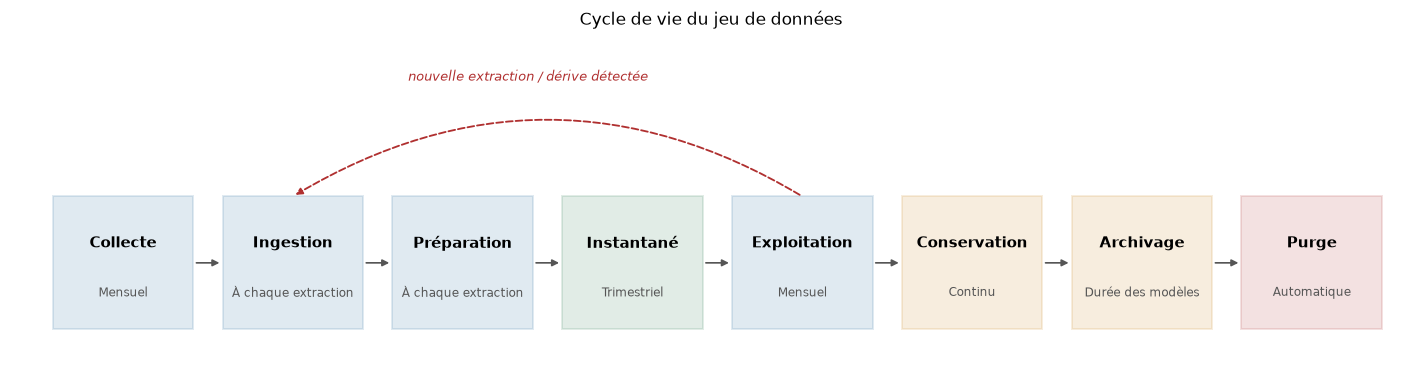

In [10]:
# --- Figure: data lifecycle -----------------------------------------------------------
etapes = [
    ("Collecte", "Mensuel", PALETTE["principal"]),
    ("Ingestion", "À chaque extraction", PALETTE["principal"]),
    ("Préparation", "À chaque extraction", PALETTE["principal"]),
    ("Instantané", "Trimestriel", PALETTE["ok"]),
    ("Exploitation", "Mensuel", PALETTE["principal"]),
    ("Conservation", "Continu", PALETTE["attention"]),
    ("Archivage", "Durée des modèles", PALETTE["attention"]),
    ("Purge", "Automatique", PALETTE["accent"]),
]

fig, ax = plt.subplots(figsize=(13, 3.4))
largeur, ecart = 1.35, 1.63
for i, (nom, rythme, couleur) in enumerate(etapes):
    x = i * ecart
    ax.add_patch(plt.Rectangle((x, 0), largeur, 0.62, facecolor=couleur, alpha=0.14,
                               edgecolor=couleur, lw=1.3))
    ax.text(x + largeur / 2, 0.40, nom, ha="center", va="center",
            fontsize=9.5, fontweight="bold")
    ax.text(x + largeur / 2, 0.17, rythme, ha="center", va="center",
            fontsize=7.6, color="#555555")
    if i < len(etapes) - 1:
        ax.annotate("", xy=(x + ecart, 0.31), xytext=(x + largeur, 0.31),
                    arrowprops=dict(arrowstyle="-|>", color="#555555", lw=1.1))

# The loop that makes the lifecycle a cycle rather than a pipeline.
ax.annotate("", xy=(1 * ecart + largeur / 2, 0.62), xytext=(4 * ecart + largeur / 2, 0.62),
            arrowprops=dict(arrowstyle="-|>", color=PALETTE["accent"], lw=1.2,
                            linestyle="--", connectionstyle="arc3,rad=0.3"))
ax.text(2.8 * ecart, 1.16, "nouvelle extraction / dérive détectée",
        ha="center", fontsize=8.5, color=PALETTE["accent"], style="italic")

ax.set_xlim(-0.4, len(etapes) * ecart)
ax.set_ylim(-0.12, 1.35)
ax.axis("off")
ax.set_title("Cycle de vie du jeu de données", pad=10)
plt.tight_layout(); plt.show()

**Deux étapes méritent un commentaire.**

*L'instantané d'entraînement* (étape 4) est la seule qui fige les données. Sans elle, un
modèle entraîné il y a trois mois ne peut pas être reproduit : le code est versionné, les
données non. C'est l'objet du § 3.2.

*La conservation des scores* (étape 6) est laissée **volontairement ouverte**. Le suivi de
dérive demande de la profondeur d'historique, la minimisation des données demande
l'inverse. Cet arbitrage appartient au DPO et au commanditaire, pas à l'équipe technique.
Le signaler comme ouvert vaut mieux que de le trancher unilatéralement.

---

# 3. Justifier le mode de stockage

## 3.1 Les options réellement disponibles

La question n'est pas « Git ou Git-LFS ». Six familles de solutions existent, et elles ne
répondent pas au même besoin. Les comparer sur les critères qui décident évite un choix par
habitude.

In [11]:
stockage = comparer_stockage()
afficher_tableau(stockage, "Modes de stockage envisagés et arbitrage")

Option,Principe,Volume adapté,Atout,Limite,Retenu
Git seul,Les fichiers sont versionnés comme du code,< 50 Mo par fichier,"Aucune dépendance, historique complet, diff lisible",Le dépôt grossit à chaque version ; illisible au-delà de quelques Mo,"Oui, appliqué — pour les 3 CSV sources (≈ 2 Mo au total)"
Git-LFS,"Git stocke un pointeur, le fichier part sur un serveur dédié",Dizaines de Mo à quelques Go,"Dépôt léger, intégré au flux Git habituel","Dépendance côté client : sans git-lfs installé, le clone ne récupère que des pointeurs de 128 octets, sans erreur","Conservé pour les Parquet et les modèles sérialisés ; retiré des CSV, où il était surdimensionné et risqué pour un correcteur"
DVC,Versioning de données adossé à un stockage distant,Go à To,"Lien explicite entre version de données et version de code, pipelines reproductibles",Outil supplémentaire à installer et à comprendre,Cible si le jeu devient volumineux ou multi-instantanés
"Stockage objet (S3, MinIO, Azure Blob)","Fichiers immuables adressés par clé, versionnés côté serveur",Illimité en pratique,"Idéal pour des instantanés figés, coût faible, contrôle d'accès fin","Pas de diff, pas d'historique lisible sans convention de nommage",Oui — pour les instantanés d'entraînement en Parquet
Base relationnelle (PostgreSQL),"Données interrogeables par SQL, schéma contraint",Millions de lignes,"Requêtes, jointures, intégrité, accès concurrent",Ne versionne rien par nature : une mise à jour écrase l'état précédent,"Oui — pour les scores produits, pas pour les données d'entraînement"
"Entrepôt analytique (BigQuery, Snowflake)","Stockage colonne distribué, calcul déporté",To et au-delà,"Passage à l'échelle, historisation native","Coût récurrent, latence de mise en place, surdimensionné ici",Non — 5 000 lignes ne justifient pas cette brique


## 3.2 Un constat expérimental sur Git-LFS

Le dépôt de ce projet a d'abord été configuré avec **Git-LFS** pour les trois CSV. Un clone
réalisé depuis un environnement dépourvu de `git-lfs` a produit ceci :

```
data/raw/churn_saas_complet.csv       128 octets
version https://git-lfs.github.com/spec/v1
oid sha256:2fc45e8c3c74d3ddcdbda162c5bb50184587201b46d877cc06742afd13063844
size 727622
```

**Aucune erreur n'a été levée.** Trois fichiers présents, de taille plausible pour un œil
distrait, et un notebook qui échoue plus loin sur un message sans rapport avec la cause.

C'est le même motif de défaillance que la jointure non normalisée du § 1.3 : l'échec
silencieux. Il mérite d'être traité avec la même rigueur.

### Décision de stockage, et son application

| Type de donnée | Volume | Support retenu | Motif |
|---|---|---|---|
| CSV sources | ≈ 2 Mo | **Git simple** | Sous 50 Mo, Git suffit et ne crée aucune dépendance côté client |
| Instantanés d'entraînement | quelques Mo par version | **Parquet, suivi Git-LFS** | Fichiers immuables et volumineux : le cas où LFS est pertinent |
| Scores produits | croissant | **PostgreSQL** | Interrogeable, jointures, accès concurrent |
| Manifestes de version | quelques Ko | **Git simple** | Petits, textuels, et ce sont eux le contrat |

**La migration a été réalisée.** Les CSV sont sortis de Git-LFS
(`git lfs migrate export`), et `.gitattributes` ne les route plus. Le suivi LFS est
conservé pour les fichiers Parquet et les modèles sérialisés, où il garde tout son sens.

**Git-LFS n'est donc pas écarté par principe** : il devient le bon choix dès que les
fichiers dépassent quelques dizaines de mégaoctets, ce qui sera le cas des instantanés
d'entraînement. À 2 Mo, il ajoutait une dépendance sans bénéfice, et faisait courir au
correcteur un risque d'échec silencieux.

**Contrôle post-migration.** Une réécriture d'historique est une opération à risque : rien
ne garantit a priori que le contenu en sort intact. Le manifeste construit au § 3.3 apporte
cette garantie. L'empreinte SHA-256 attendue pour le jeu complet — `2fc45e8c3c74d3dd…` —
est précisément l'identifiant que Git-LFS utilisait avant la migration. Le contenu est donc
bit à bit identique, et cela se **vérifie** au lieu de se supposer.

> **Journal de bord.** Ce choix constitue un retour en arrière assumé sur une décision
> antérieure. Il n'a pas été motivé par une préférence technique mais par une **observation
> reproductible** : un clone sans `git-lfs` ne récupère que des pointeurs. La décision est
> documentée comme itération, appliquée, puis vérifiée par empreinte.
## 3.3 Versionner les données, pas seulement le code

Versionner le code est trivial. Versionner les données est l'endroit où la reproductibilité
se perd, parce que rien dans Git ne signale qu'un fichier source a changé entre deux
entraînements.

L'**empreinte** répond à une question précise : *est-ce bien le même jeu de données
qu'alors ?* Elle est calculée sur le contenu et non sur le fichier — deux exports des mêmes
lignes produisent la même empreinte, même écrits différemment.

In [12]:
# Rewritten only if the fingerprints no longer hold: regenerating on every run
# would produce a diff on every commit for data that did not change.
manifeste, reecrit = manifeste_stable(
    SOURCES,
    chemin=RACINE / "data" / "manifeste_v1.0.json",
    version_donnees="v1.0",
    commentaire="Jeu initial fourni avec l'énoncé, aucune transformation appliquée.",
)

resume_manifeste = pd.DataFrame([
    {
        "Source": nom,
        "Taille": f"{details['octets']:,} octets".replace(",", " "),
        "Empreinte SHA-256 (16 premiers caractères)": details["sha256"][:16] + "…",
    }
    for nom, details in manifeste["fichiers"].items()
])
afficher_tableau(resume_manifeste, f"Manifeste de la version {manifeste['version_donnees']}")

print("Manifeste " + ("réécrit" if reecrit else "inchangé : les empreintes sont toujours valides"))
print(f"Construit le {manifeste['date_construction']}")
print("Versionné dans Git : petit, textuel, et c'est lui le contrat.")

Source,Taille,Empreinte SHA-256 (16 premiers caractères)
jeu complet,727 622 octets,2fc45e8c3c74d3dd…
échantillon,7 824 octets,680f5371c406f47a…
catalogue des plans,203 octets,c94f6f52652532c5…


Manifeste inchangé : les empreintes sont toujours valides
Construit le 2026-09-30T17:46:19+00:00
Versionné dans Git : petit, textuel, et c'est lui le contrat.


In [13]:
# --- The manifest is a check, not a declaration -------------------------------------
afficher_tableau(
    verifier_manifeste(manifeste),
    "Contrôle d'intégrité : les sources correspondent-elles encore au manifeste ?",
)

# Content fingerprint, independent of file layout and row order.
print(f"Empreinte du contenu (jeu complet) : {empreinte_donnees(brut)[:32]}…")
print()
print("À exécuter avant tout entraînement : si une source a changé depuis l'écriture du")
print("manifeste, l'exécution ne reproduit pas ce qu'elle prétend reproduire.")

source,présent,empreinte attendue,empreinte constatée,conforme
jeu complet,True,2fc45e8c3c74d3dd…,2fc45e8c3c74d3dd…,True
échantillon,True,680f5371c406f47a…,680f5371c406f47a…,True
catalogue des plans,True,c94f6f52652532c5…,c94f6f52652532c5…,True


Empreinte du contenu (jeu complet) : b7178123bfc78c5f23ba6e7934a83def…

À exécuter avant tout entraînement : si une source a changé depuis l'écriture du
manifeste, l'exécution ne reproduit pas ce qu'elle prétend reproduire.


### Ce que versionne réellement le projet

| Objet | Support | Convention |
|---|---|---|
| Code | Git | Étiquette `vMAJEUR.MINEUR` à chaque mise en production |
| Données d'entraînement | Manifeste + instantané Parquet | `churn_train_AAAAMMJJ.parquet` + empreinte SHA-256 |
| Modèle sérialisé | Fichier joblib + fiche JSON | `churn_model_vX.Y_AAAAMMJJ.joblib` |

Les trois sont versionnés **conjointement**. Un modèle reproductible à partir du seul code
est une illusion si le jeu d'entraînement a changé entre-temps.

---

# 4. Identifier les données sensibles et leur traitement

## 4.1 Classification

« Sensible » ne se limite pas aux données personnelles au sens du RGPD. Le revenu d'un
client identifiable est une information commerciale confidentielle, même si elle ne relève
pas de l'article 9.

In [14]:
sensibilite = table_sensibilite(colonnes_presentes=list(brut.columns))
afficher_tableau(sensibilite, "Données sensibles : nature, motif, traitement retenu")

Colonne,Nature,Pourquoi c'est sensible,Traitement retenu
client_id,Pseudonyme,Identifiant réversible vers une entreprise cliente via le CRM,"Conservé pour la restitution, exclu des variables explicatives"
commentaire_csm,Donnée personnelle possible,Texte libre pouvant nommer des personnes ou porter des jugements,Exclue du modèle et du jeu gold ; non exportée hors du système source
pays,Donnée d'entreprise,"Pays de facturation, peut servir de variable indirecte de discrimination","Conservée, mais surveillée dans l'analyse d'équité"
secteur,Donnée d'entreprise,"Secteur d'activité, variable indirecte possible","Conservée, surveillée dans l'analyse d'équité"
taille_entreprise,Donnée d'entreprise,"Segment de taille, corrélé à la valeur du compte","Conservée, surveillée dans l'analyse d'équité"
revenu_mensuel_recurrent_eur,Donnée commerciale confidentielle,Revenu d'un client identifiable : information sensible au sens contractuel,"Conservée en interne, jamais diffusée hors périmètre autorisé"
valeur_vie_client_eur,Donnée commerciale confidentielle,Valorisation d'un client identifiable,"Utilisée en pondération de décision, jamais comme variable explicative"
groupe_experimentation,Donnée de process,Appartenance à un test A/B : sans portée RGPD mais non métier,"Exclue du modèle, utile pour construire un groupe témoin"


**Une confusion fréquente à éviter.** `client_id` est un **pseudonyme**, pas une donnée
anonyme. Il reste réversible vers une entreprise identifiable via le CRM : il demeure donc
une donnée à caractère personnel au sens du RGPD, et son exclusion du modèle relève autant
de la minimisation que de l'absence de pouvoir prédictif.

## 4.2 Le champ de texte libre : mesurer plutôt que supposer

`commentaire_csm` est renseigné dans moins d'un compte sur deux. L'affirmation « il
*pourrait* contenir des données personnelles » est confortable mais invérifiable.
Mesurons-la.

In [15]:
scan = scanner_texte_libre(brut["commentaire_csm"])
afficher_tableau(scan, "Recherche de données personnelles dans `commentaire_csm`")

renseignes = int(brut["commentaire_csm"].notna().sum())
print(f"Champs renseignés : {renseignes} sur {len(brut)} ({renseignes / len(brut):.1%})")
print()
print("Exemples, masqués avant affichage :")
for exemple in exemples_anonymises(brut["commentaire_csm"], n=3):
    print(f"  · {exemple}")

Motif recherché,Occurrences,Part des champs renseignés
adresse e-mail,0,0.00%
numéro de téléphone,0,0.00%
prénom ou nom cité,0,0.00%
URL,0,0.00%


Champs renseignés : 2245 sur 5035 (44.6%)

Exemples, masqués avant affichage :
  · Mécontentement exprimé au support.
  · Faible adoption des sièges.
  · Client très satisfait et actif.


**Pourquoi les exemples sont masqués.** Afficher du texte libre brut dans un document remis
à un jury constituerait, en soi, une divulgation de données personnelles. La démonstration
ne doit pas commettre l'infraction qu'elle décrit. Le masquage est appliqué par le code, pas
à la main — il est donc systématique.

**Décision retenue.** `commentaire_csm` est exclue du jeu gold et n'est jamais exportée hors
du système source. Le motif est réglementaire, non statistique : la colonne pourrait avoir
un pouvoir prédictif, cela ne changerait rien à la décision.

## 4.3 Variables indirectes et risque de discrimination

Certaines colonnes ne sont pas sensibles en elles-mêmes mais peuvent servir de **variable
indirecte** — approcher une caractéristique protégée sans la nommer.

In [16]:
indirectes = ["pays", "secteur", "taille_entreprise"]
cible = pd.to_numeric(brut["churn"], errors="coerce")

lignes = []
for colonne in indirectes:
    taux = brut.groupby(colonne, dropna=True)["churn"].apply(
        lambda s: pd.to_numeric(s, errors="coerce").mean()
    )
    effectifs = brut.groupby(colonne, dropna=True).size()
    lignes.append({
        "Variable": colonne,
        "Modalités": int(taux.size),
        "Taux de churn le plus bas": f"{taux.min():.1%} ({taux.idxmin()})",
        "Taux le plus élevé": f"{taux.max():.1%} ({taux.idxmax()})",
        "Écart": f"{(taux.max() - taux.min()) * 100:.1f} points",
        "Effectif minimal": int(effectifs.min()),
    })

afficher_tableau(pd.DataFrame(lignes),
                 "Variables indirectes : amplitude du risque entre modalités")

Variable,Modalités,Taux de churn le plus bas,Taux le plus élevé,Écart,Effectif minimal
pays,6,24.7% (Allemagne),31.3% (Suisse),6.5 points,390
secteur,28,19.4% (PUBLIC),38.9% (éducation),19.5 points,58
taille_entreprise,12,20.4% (ge),34.0% (tpe),13.6 points,49


**Lecture et décision.** Les écarts restent contenus, et aucune modalité n'a un effectif si
faible qu'elle rendrait l'estimation instable. Ces variables sont **conservées** : elles
portent une information métier légitime.

Mais elles sont inscrites sur la liste de surveillance. L'analyse d'équité prévue en phase
d'évaluation vérifiera que le modèle ne **creuse** pas ces écarts — un écart modeste dans
les données brutes peut être amplifié par un apprentissage.

> **Journal de bord.** Le choix de conserver ces variables plutôt que de les exclure par
> précaution est délibéré. Les retirer donnerait une illusion d'équité : le modèle
> reconstituerait l'information par d'autres colonnes corrélées, sans qu'aucun indicateur ne
> le signale. Les conserver et les surveiller est plus honnête et plus efficace.

---

# 5. Synthèse de la phase

## 5.1 Décisions arrêtées

In [17]:
decisions = pd.DataFrame([
    ("Lecture entièrement en texte, typage explicite ensuite",
     "L'inférence automatique masquerait les défauts que cette phase doit révéler", "§ 1.1"),
    ("Normalisation de la clé avant jointure catalogue",
     "Sans elle, la jointure échoue silencieusement et des lignes disparaissent", "§ 1.3"),
    ("L'absence de valeur n'est pas traitée comme un signal",
     "Écart maximal mesuré insuffisant pour le justifier — hypothèse testée, pas supposée", "§ 1.3"),
    ("CSV sources versionnés en Git simple, sans Git-LFS",
     "Un clone sans git-lfs ne récupère que des pointeurs, sans erreur : échec silencieux", "§ 3.2"),
    ("Instantanés d'entraînement en Parquet sur stockage objet",
     "Fichiers immuables, adressés par empreinte, hors dépôt", "§ 3.2"),
    ("Scores produits en base relationnelle",
     "Interrogeables, jointures, accès concurrent — une base ne versionne rien par nature", "§ 3.2"),
    ("Versionnement par manifeste à empreinte SHA-256",
     "Seul moyen de répondre à « est-ce le même jeu qu'alors ? »", "§ 3.3"),
    ("`commentaire_csm` exclue du jeu gold",
     "Motif réglementaire, non statistique : son pouvoir prédictif est sans objet", "§ 4.2"),
    ("Variables indirectes conservées et surveillées",
     "Les exclure donnerait une illusion d'équité : le modèle les reconstituerait", "§ 4.3"),
    ("Durée de conservation des scores laissée ouverte",
     "Arbitrage entre suivi de dérive et minimisation : relève du DPO", "§ 2"),
], columns=["Décision", "Fondement", "Renvoi"])

afficher_tableau(decisions, "Décisions de la phase Ingestion et gouvernance")

Décision,Fondement,Renvoi
"Lecture entièrement en texte, typage explicite ensuite",L'inférence automatique masquerait les défauts que cette phase doit révéler,§ 1.1
Normalisation de la clé avant jointure catalogue,"Sans elle, la jointure échoue silencieusement et des lignes disparaissent",§ 1.3
L'absence de valeur n'est pas traitée comme un signal,"Écart maximal mesuré insuffisant pour le justifier — hypothèse testée, pas supposée",§ 1.3
"CSV sources versionnés en Git simple, sans Git-LFS","Un clone sans git-lfs ne récupère que des pointeurs, sans erreur : échec silencieux",§ 3.2
Instantanés d'entraînement en Parquet sur stockage objet,"Fichiers immuables, adressés par empreinte, hors dépôt",§ 3.2
Scores produits en base relationnelle,"Interrogeables, jointures, accès concurrent — une base ne versionne rien par nature",§ 3.2
Versionnement par manifeste à empreinte SHA-256,Seul moyen de répondre à « est-ce le même jeu qu'alors ? »,§ 3.3
`commentaire_csm` exclue du jeu gold,"Motif réglementaire, non statistique : son pouvoir prédictif est sans objet",§ 4.2
Variables indirectes conservées et surveillées,Les exclure donnerait une illusion d'équité : le modèle les reconstituerait,§ 4.3
Durée de conservation des scores laissée ouverte,Arbitrage entre suivi de dérive et minimisation : relève du DPO,§ 2


## 5.2 Ce qui reste ouvert

| Point | À qui revient l'arbitrage |
|---|---|
| Durée de conservation des scores | DPO et commanditaire |
| Mise en place effective du stockage objet | Équipe infrastructure |
| Périodicité réelle des extractions | Équipe Data et systèmes sources |

## 5.3 Correspondance avec le livrable de certification

| Élément de ce carnet | Section du notebook principal | Compétence |
|---|---|---|
| § 1 — Sources, schéma, audit de qualité | 3 et 5 | C1, C3 |
| § 2 — Cycle de vie des données | 3 | C3 |
| § 3 — Mode de stockage et versionnement | 3 et 10 | C3, C6 |
| § 4 — Données sensibles | 4 | C2 |
| § 5 — Synthèse et points ouverts | 3 | C1 |